<a href="https://colab.research.google.com/github/Sanika-tech123/Advanced-Machine-Learning-Practicals/blob/main/K-Medoids%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Iris.csv to Iris.csv
First 5 rows of dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 2 0 0 1 2 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0
 0 2 2 2 0 0 0 0 0 0 1 0 2 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 2 0 2 2 1 2 2 2 2
 0 2 0 0 0 2 2 2 0 2 0 2 0 2 2 0 0 0 2 2 2 0 0 0 2 0 0 0 2 2 2 0 2 2 2 0 2
 0 0]

Medoid Centers:
[[6.  2.9]
 [5.  3.4]
 [6.9 3.1]]


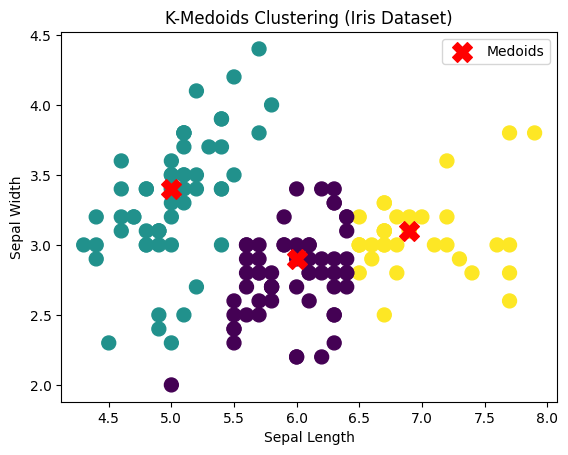

In [ ]:
# Step 1 — Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 2 — Upload dataset
uploaded = files.upload()

# Step 3 — Load dataset
data = pd.read_csv("Iris.csv")

# Step 4 — Display dataset preview
print("First 5 rows of dataset:")
print(data.head())

# Step 5 — Select features for clustering
X = data[['SepalLengthCm','SepalWidthCm']].values

# Step 6 — Define K-Medoids algorithm
def k_medoids(X, k, max_iter=100):

    np.random.seed(42)
    medoid_indices = np.random.choice(len(X), k, replace=False)
    medoids = X[medoid_indices]

    for _ in range(max_iter):

        # Assign clusters
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_medoids = []

        for i in range(k):
            cluster_points = X[labels == i]

            if len(cluster_points) == 0:
                new_medoids.append(medoids[i])
                continue

            dist_matrix = np.sum(
                np.linalg.norm(cluster_points[:, np.newaxis] - cluster_points, axis=2),
                axis=1
            )

            new_medoids.append(cluster_points[np.argmin(dist_matrix)])

        new_medoids = np.array(new_medoids)

        if np.all(medoids == new_medoids):
            break

        medoids = new_medoids

    return labels, medoids

# Step 7 — Apply K-Medoids clustering
labels, medoids = k_medoids(X, k=3)

print("\nCluster Labels:")
print(labels)

print("\nMedoid Centers:")
print(medoids)

# Step 8 — Visualize clusters
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=100)

plt.scatter(medoids[:,0], medoids[:,1],
            color='red',
            marker='X',
            s=200,
            label='Medoids')

plt.title("K-Medoids Clustering (Iris Dataset)")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

plt.show()